# 3. Candidate evaluation discussion

This notebook follows one worked single-slot PHY candidate through the current evaluation path until the stored operating row is resolved. The aim here is to show the artifacts that the code builds, not to restate the theory.

The row's `p_out_total_w` is the complete active-slot RF output for the allocation. Its `p_dc_active_w` is evaluated from that total RF output through the PA curve and scaled by the row's PRB fraction.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

for path in (repo_root / "notebooks", repo_root / "src"):
    resolved = str(path.resolve())
    if resolved not in sys.path:
        sys.path.insert(0, resolved)

from helpers.candidate_evaluation_helpers import CandidateEvaluationHelpers

# Notebook-wide visual identity: change this once to rerun under the other institutional theme.
helper = CandidateEvaluationHelpers(theme="aalto_elec")
artifacts = helper.build_artifacts()

def show_figure(fig):
    display(fig)
    plt.close(fig)


## 1. Fixed scenario context

This notebook reopens only the shared assumptions needed to evaluate one candidate. The fixed 3GPP NR PDSCH preset, carrier, and resource envelope are carried forward from the scenario notebook and kept compact here.


In [2]:
display(
    helper.render_table(
        artifacts.scenario_context,
        caption="Shared scenario context carried into the worked candidate evaluation.",
    )
)


item,value
Downlink channel,3GPP NR PDSCH over the fixed micro-cell preset
Carrier preset,"100 MHz at 3.5 GHz, 30 kHz SCS"
Resource envelope,20 slots x 277 PRBs x 4 ranks
Worked distance,200 m
Comparison distance,500 m
Worked candidate class,"pa_id = 0, n_prb = 96, n_slots_on = 1, layers = 2, mcs = 14"


## 2. Worked candidate geometry

The worked object in this notebook is one single-slot PHY operating point. It occupies one active slot, one PRB span, one spatial rank count, one PA choice, and one MCS.


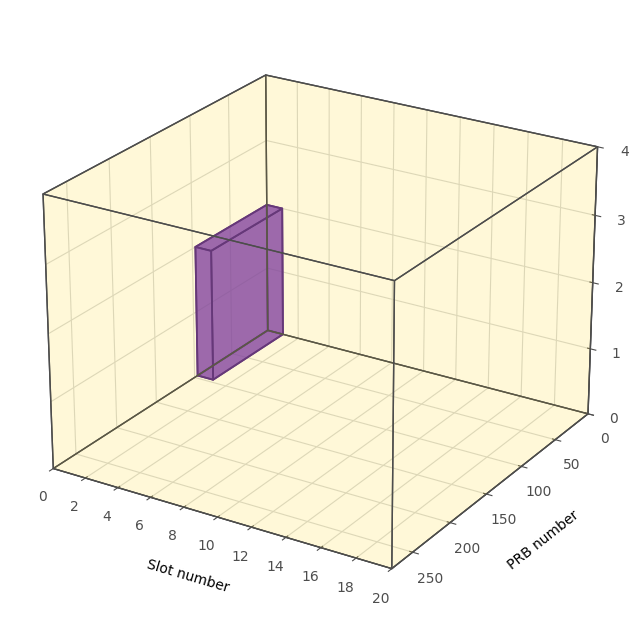

In [3]:
fig, _ = helper.plot_candidate_geometry(artifacts)
show_figure(fig)


**Figure 3.1. One worked single-slot candidate inside the fixed NR resource envelope.**

The shaded block is one active slot with `n_prb = 96` across `layers = 2` on `pa_id = 0`.
This is one PHY operating point, not a schedule.


## 3. Slot payload accounting

The rate side of the model first resolves how many payload-bearing resource elements remain in one active slot for this candidate.


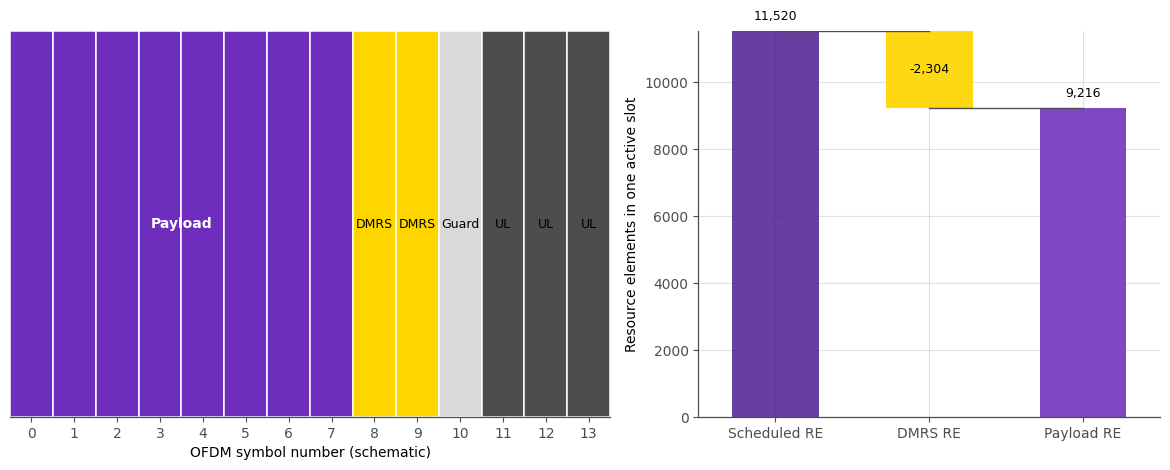

In [4]:
fig, _ = helper.plot_slot_payload_accounting(artifacts)
show_figure(fig)


**Figure 3.2. Slot-level payload accounting for the worked candidate.**

The left panel is schematic. In code, the payload path uses `n_sym_data = 10` scheduled downlink symbols and subtracts `n_dmrs_sym = 2` DMRS symbols from that pool.
For this candidate, the accounting resolves `n_re_raw = 11,520`, `n_pilot = 2,304`, and `n_re_data = 9,216`.


## 4. MCS requirement resolution

The candidate carries one fixed MCS. The current model resolves the corresponding target from the active MCS requirement table and then passes that target into the power solve.


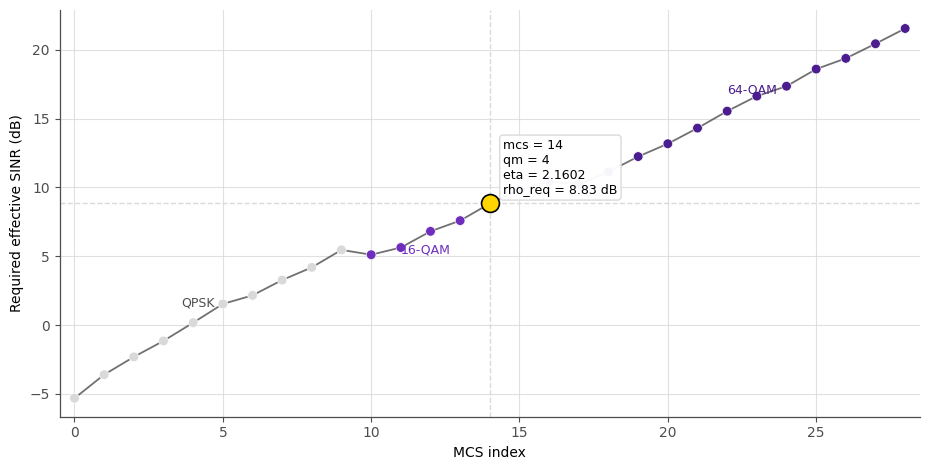

In [5]:
fig, _ = helper.plot_mcs_requirement(artifacts)
show_figure(fig)


**Figure 3.3. MCS requirement resolution for the worked candidate.**

The curve is the current requirement table built by `McsRequirementModel`.
The highlighted point is the worked row: `mcs = 14`, `qm = 4`, `eta = 2.1602`, and `rho_req = 8.83 dB`.


## 5. Link-budget and effective-SINR solve

The center of the notebook is the current solve chain from the worked candidate and the distance-conditioned deployment state to the minimum source-power point that still meets the target.


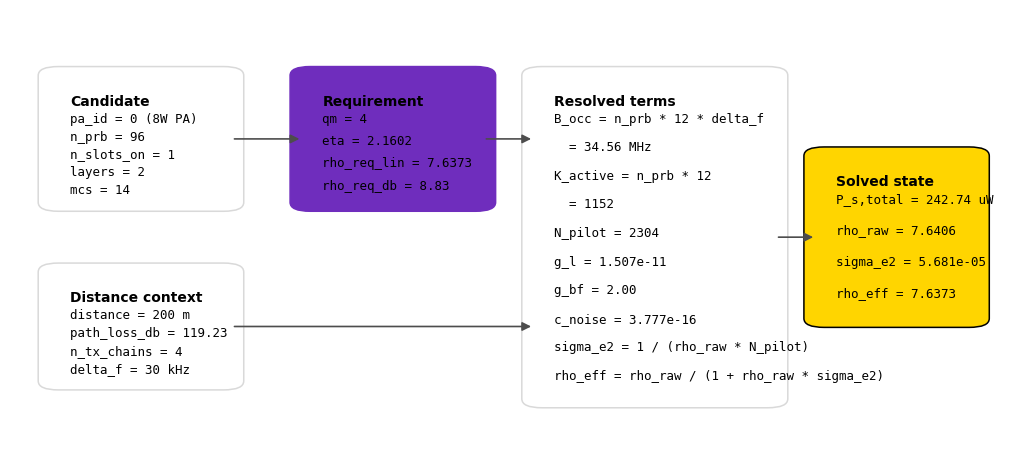

In [6]:
fig, _ = helper.plot_link_budget_chain(artifacts)
show_figure(fig)


**Figure 3.4. Link-budget and effective-SINR solve for the worked candidate at `200 m`.**

The diagram follows the current model path from the candidate geometry and the distance-conditioned deployment state to the solved source-power point.
This notebook stops at this solved single-slot operating point and does not move into frontier generation or user-rate scaling.


## 6. RF operating point and active PA quantities

Once the solve closes, the candidate has one explicit RF operating point and one attached active PA state.


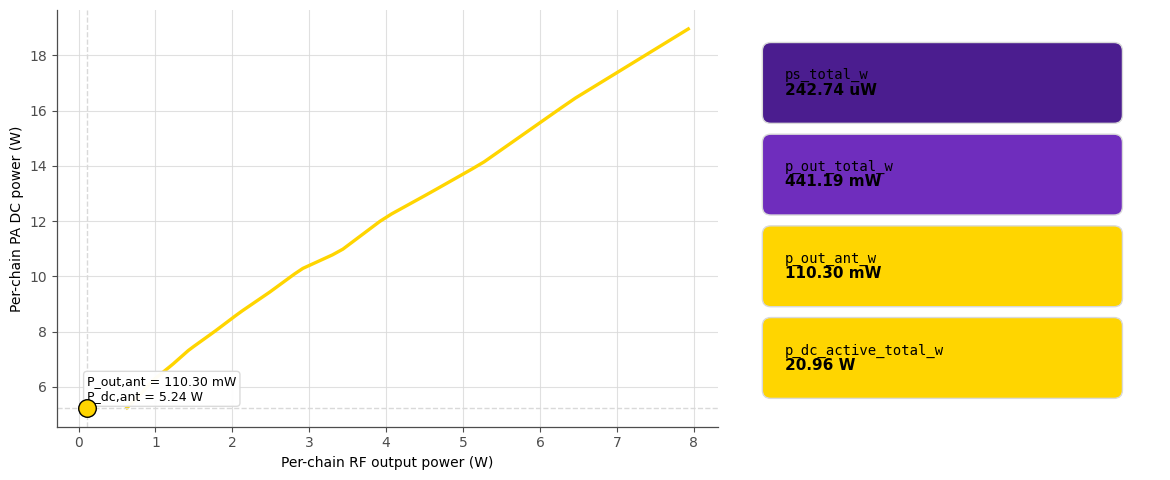

In [7]:
fig, _ = helper.plot_rf_operating_point(artifacts)
show_figure(fig)


**Figure 3.5. Solved RF operating point on the selected PA curve.**

The left panel places the worked per-chain operating point on the measured `8W PA` curve.
The right panel keeps the active-slot quantities explicit: source power, RF output power, per-chain output power, and total active PA DC power.


## 7. Evaluated candidate record

At this stage, the worked candidate can be shown as the compact row artifact that later notebooks reuse.


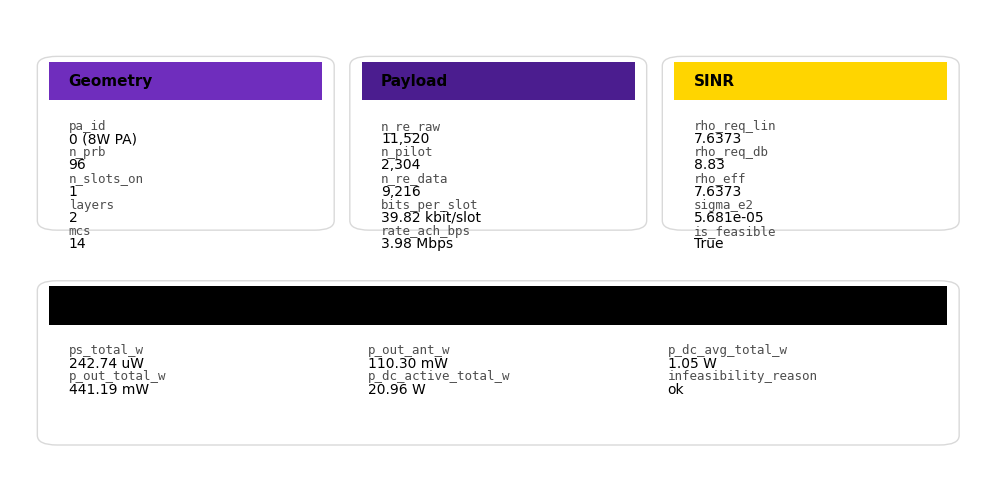

In [8]:
fig, _ = helper.plot_evaluated_candidate_record(artifacts)
show_figure(fig)


**Figure 3.6. Final evaluated candidate record carried forward from this notebook.**

The card uses the current implementation fields.
The physical operating point is the active-slot state; the attached `rate_ach_bps` and `p_dc_avg_total_w` fields remain in the row because they are part of the present contract.


## 8. The same candidate class at two distances

The last view keeps the candidate geometry fixed and changes only the link distance. This is the narrow bridge from one worked row toward the later distance-binned candidate space.


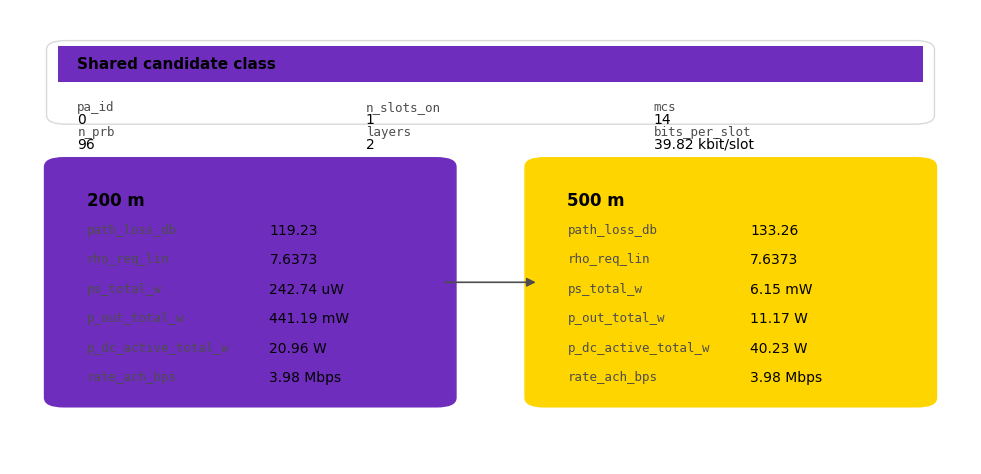

In [9]:
fig, _ = helper.plot_distance_comparison(artifacts)
show_figure(fig)


**Figure 3.7. The same candidate class resolved at `200 m` and `500 m`.**

The geometry and MCS stay fixed while path loss and the solved power quantities change.
This is the bridge to the later notebook, where many rows of this class are enumerated and compared across distance bins.


## 9. Handoff

This notebook stops at one evaluated single-slot operating row.

The later steps in the sequence enumerate these rows across fixed distances, prune the stored frontiers, retrieve rows for users, and scale them into the scheduler preparation path.
